In [1]:
import umap
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.manifold import trustworthiness

from pathlib import Path
import os 

/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
BASE_DIR = Path("umap_components.ipynb").resolve().parent.parent.parent
csv_name = os.path.join(BASE_DIR, "data", "2026-02-MD_processed.csv")

In [3]:
X = pd.read_csv(
    csv_name,
    index_col = 0
)

X.describe()

,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
count,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,...,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02
mean,-1.769720e-17,-4.424301e-18,-1.283047e-16,2.433366e-17,5.751591e-17,4.424301e-18,-1.769720e-17,8.848602e-18,2.654581e-17,-8.848602e-18,...,-1.603809e-17,1.548505e-17,8.986861e-18,9.954677e-18,1.576157e-17,5.475072e-17,-6.359933e-18,5.806895e-18,-1.714417e-17,-1.283047e-16
std,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,...,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00
min,-6.761413e+00,-7.279620e+00,-5.058460e+00,-4.728367e+00,-7.662762e+00,-5.560631e+00,-6.422312e+00,-6.232835e+00,-5.573585e+00,-7.414389e+00,...,-6.103380e+00,-5.974399e+00,-7.548948e+00,-6.432713e+00,-5.699788e+00,-5.030395e+00,-6.002442e+00,-7.235000e+00,-7.896912e+00,-1.432422e+00
25%,-3.371927e-01,-4.410713e-01,-4.814260e-01,-5.011383e-01,-4.371995e-01,-4.743347e-01,-5.291382e-01,-4.974936e-01,-5.304167e-01,-4.234299e-01,...,-4.300059e-01,-5.286050e-01,-5.473831e-01,-4.041837e-01,-5.103916e-01,-4.193538e-01,-3.308075e-01,-3.451407e-01,-5.279421e-01,-7.009149e-01
50%,2.787385e-02,4.047215e-02,-3.227340e-02,-6.088243e-03,2.744100e-02,2.835483e-02,7.956988e-03,-5.966010e-03,-1.149576e-03,1.800293e-02,...,2.750645e-03,-3.968677e-02,-2.888757e-03,-1.146269e-02,-1.888919e-03,-1.044273e-02,1.155477e-02,4.998966e-02,3.807775e-02,-2.072798e-01
75%,4.131000e-01,4.588318e-01,5.117966e-01,5.135632e-01,4.671353e-01,5.121791e-01,5.485987e-01,5.482236e-01,5.155903e-01,4.412737e-01,...,4.735303e-01,4.975496e-01,4.948990e-01,3.824777e-01,4.488970e-01,4.269765e-01,3.212293e-01,4.359867e-01,5.337208e-01,4.281468e-01
max,7.418563e+00,7.263242e+00,9.026554e+00,6.738309e+00,7.463401e+00,7.247277e+00,8.263393e+00,9.144872e+00,8.715777e+00,7.346835e+00,...,4.520144e+00,1.010574e+01,4.937993e+00,6.263905e+00,5.267733e+00,5.067201e+00,6.040932e+00,8.036008e+00,4.639053e+00,6.375515e+00


In [4]:
def fit_umap(X: pd.DataFrame,
             n_components: int = 4,
             n_neighbors: int = 15,
             min_dist: float = 0.0,
             random_state: int = 42):
    
    mapper = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=random_state
    )

    X_reduced = mapper.fit_transform(X.values)

    X_reduced_df = pd.DataFrame(
        X_reduced, 
        index=X.index, 
        columns=[f"UMAP_{i+1}" for i in range(n_components)]
    )

    return X_reduced_df, mapper


In [5]:
components = [c for c in range(2,10)]
n_neighbors_trust = [n for n in range(3, 10)]


results = {
    "components": [],
    "n_neighbors": [],
    "trustworthiness":[]
}

for comp in components:
    for r in n_neighbors_trust:
        X_embedded, _ = fit_umap(
            X,
            n_components = comp,
            n_neighbors = r,
        )

        trust = trustworthiness(X=X, X_embedded=X_embedded, n_neighbors=r)

        results["components"].append(comp)
        results["n_neighbors"].append(r)
        results["trustworthiness"].append(trust)


res = pd.DataFrame(results).sort_values(by = "trustworthiness", ascending=False)

/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeW

In [6]:
res.sort_values(by= ["n_neighbors", "trustworthiness"])

,components,n_neighbors,trustworthiness
0,2,3,0.847216
7,3,3,0.849451
42,8,3,0.851997
14,4,3,0.855764
28,6,3,0.855829
21,5,3,0.858941
49,9,3,0.859310
35,7,3,0.864641
1,2,4,0.827299
15,4,4,0.840328


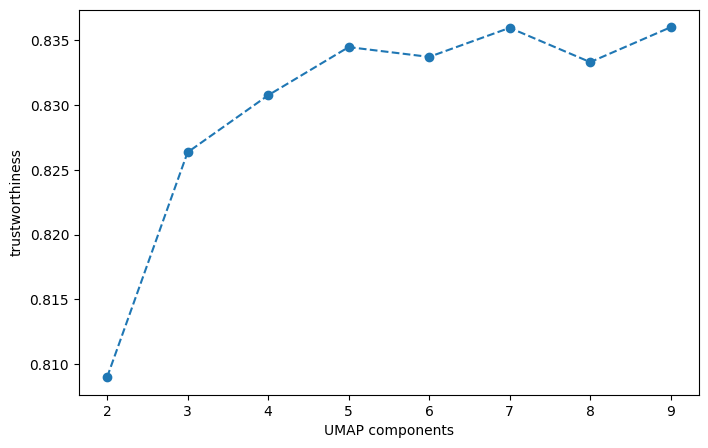

In [7]:
fig, ax = plt.subplots(figsize = (8,5))


ax.plot(res.groupby("components")["trustworthiness"].mean(), marker = 'o', linestyle = '--')
plt.ylabel("trustworthiness")
plt.xlabel("UMAP components")
plt.show()

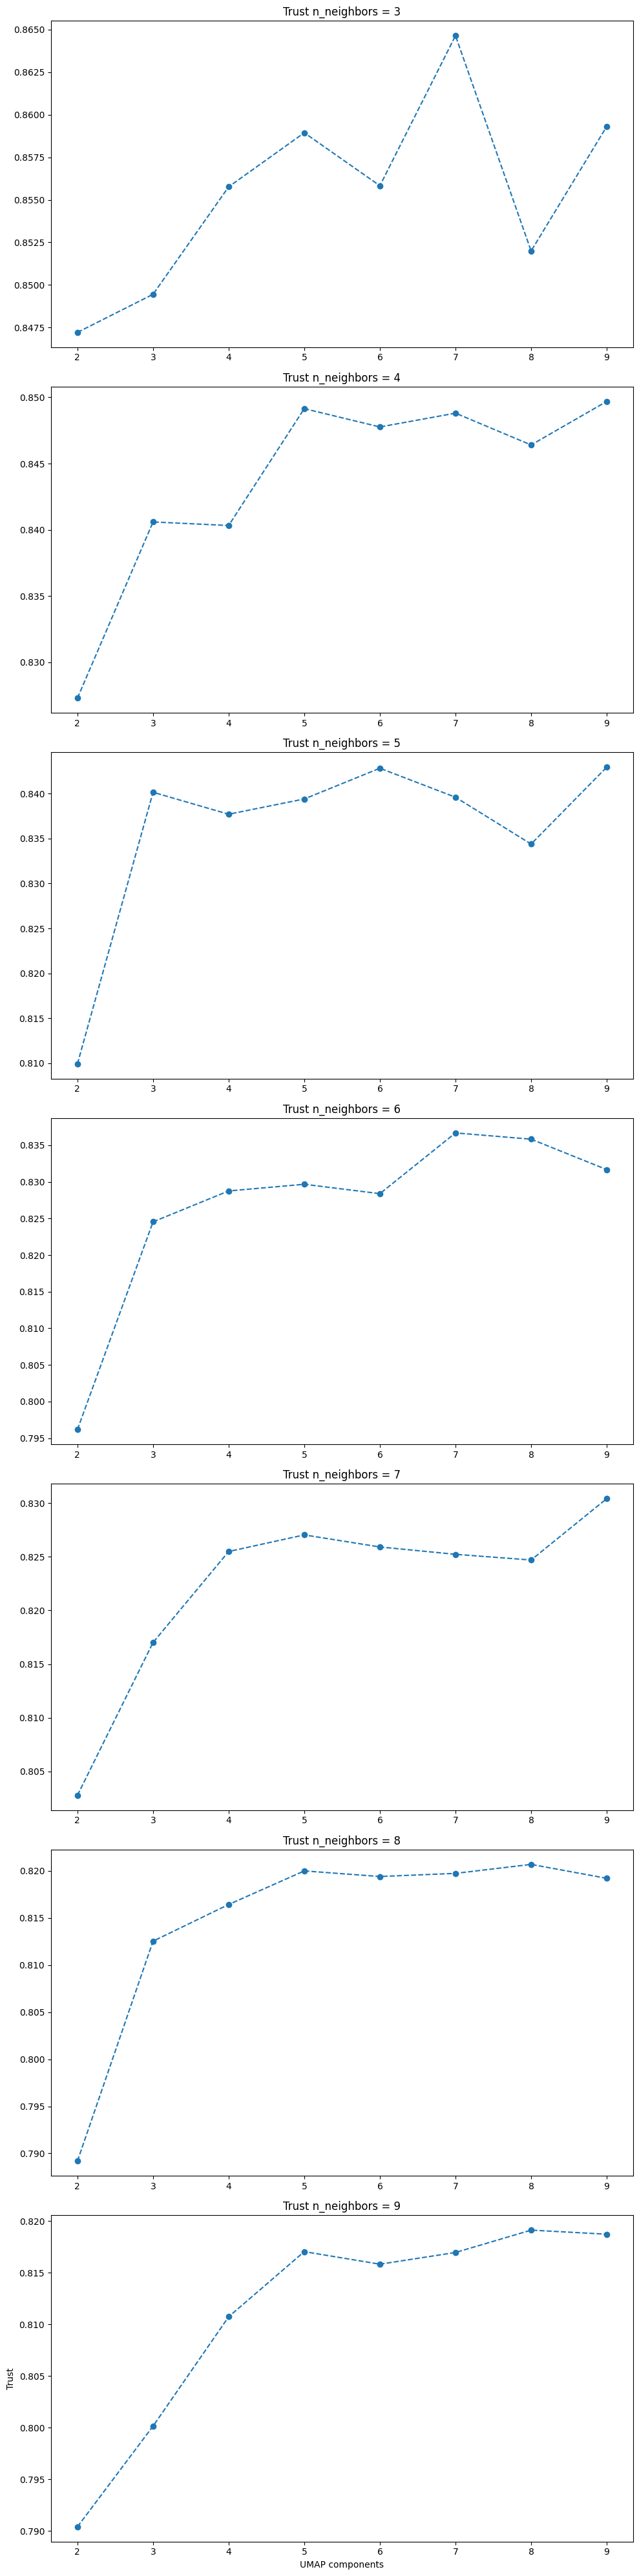

In [ ]:
n_plots_neighbors = len(n_neighbors_trust)

fig, ax = plt.subplots(nrows = n_plots_neighbors, ncols = 1, figsize = (10,40))
ax = ax.flatten()

data = pd.Series(res.sort_values("components").groupby("n_neighbors")["trustworthiness"])

for i, n in zip(range(n_plots_neighbors), n_neighbors_trust):
    neigh, d = data.loc[i]
    ax[i].plot(components,d, marker = "o", linestyle = '--')
    ax[i].set_title(f"Trust n_neighbors = {neigh}")
    plt.xlabel("UMAP components")
    plt.ylabel("Trust")

plt.tight_layout()